In [1]:
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt 

from snudd         import config
from snudd.targets import Nucleus
from snudd.geometry import SolarAngles
from snudd.models       import GeneralNSI, SM

from snudd.resolution   import Resolution, Convolver # deals with the resolution effects on the rate

from snudd.resolution   import res_lz_nr, res_xnt_nr, res_panda_nr # these are the resolution functions for the different experiments
from snudd.efficiencies import efficiency_lz_b8, efficiency_pandaX, efficiency_xnt_2025

## Detector convolution function

In [2]:
def counts_LZB8_NR(signal, E_Rs):
    #### from https://arxiv.org/pdf/2512.08065 
    exposure =  5.7 # in tn yr-1
    convolution_lz_sig = Convolver(E_Rs, signal , efficiency_lz_b8, res_lz_nr)
    return convolution_lz_sig.convolved_binned_rate(1.0e-7, 1.5e-5)*exposure 


def counts_XNT2025_NR(signal, E_Rs):
    #### from https://arxiv.org/pdf/2408.02877 
    exposure =  3.51 # in tn yr-1
    convolution_xnt_sig = Convolver(E_Rs, signal , efficiency_xnt_2025, res_xnt_nr)
    return convolution_xnt_sig.convolved_binned_rate(1.0e-7, 1.5e-5)*exposure 


def counts_PANDA_NR(signal, E_Rs):
    #### from https://arxiv.org/pdf/2407.10892
    exposure =  1.20 # in tn yr-1
    convolution_panda_sig = Convolver(E_Rs, signal , efficiency_pandaX, res_panda_nr)
    return convolution_panda_sig.convolved_binned_rate(1.0e-7, 1.5e-5)*exposure

## Detector locations

In [3]:
latitude_surf = 44.35 # Latitude of SURF (LZ)
latitude_gs   = 42.47 # Latitude of Gran Sasso
latitude_panda = 28.15 # Latitude of Jinping

# Define data taking period 
t0 = 91     # Starting at the perihelion (January 3rd) 
T  = 182*2  # Length of data taking period in days 

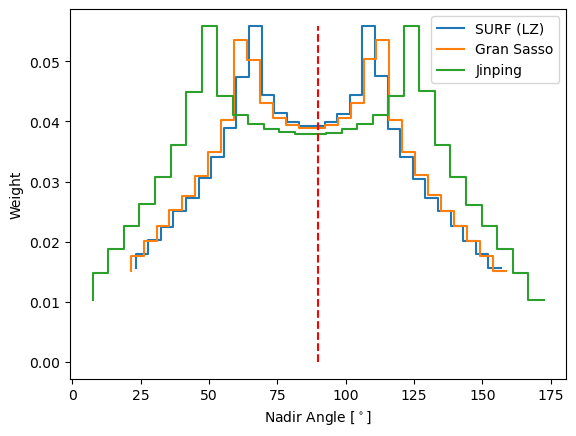

In [4]:
# Get angular histograms
SURF      = SolarAngles(latitude=latitude_surf, t0=t0, T=T)
GranSasso = SolarAngles(latitude=latitude_gs, t0=t0, T=T)
Jinping   = SolarAngles(latitude=latitude_panda, t0=t0, T=T)

# Generate nadir angle histogram
nbins = 30
cnadirs_surf, weights_surf = SURF.cnadir_hist(bins=nbins)
cnadirs_gran, weights_gran = GranSasso.cnadir_hist(bins=nbins)
cnadirs_jinping, weights_jinping = Jinping.cnadir_hist(bins=nbins)

# Plot the histogram of nadir angles with weights
nadirs_surf = np.arccos(cnadirs_surf) * 180 / np.pi  # Convert cnadirs to nadir angles in degrees
nadirs_gran = np.arccos(cnadirs_gran) * 180 / np.pi  # Convert cnadirs to nadir angles in degrees
nadirs_jinping = np.arccos(cnadirs_jinping) * 180 / np.pi  # Convert cnadirs to nadir angles in degrees

# wd = (nadirs_surf.max() - nadirs_surf.min()) / (nbins - 1)
# plt.bar(nadirs_surf, weights_surf, width=wd, )
plt.step(nadirs_surf, weights_surf, label='SURF (LZ)')
plt.step(nadirs_gran, weights_gran, label='Gran Sasso')
plt.step(nadirs_jinping, weights_jinping, label='Jinping')
plt.vlines(90, 0, max(weights_surf), color='red', linestyle='--')
plt.xlabel(r'Nadir Angle [$^\circ$]')
plt.ylabel('Weight')
plt.legend()

## Average over isotopes

In [5]:
Z_xe = 54

# Isotopic weight with relative abundance
xe_iso_data_full = np.array([[124, 123.905893  * config.u, 0.00095],
                        [126, 125.904274  * config.u, 0.00089],
                        [128, 127.9035313 * config.u, 0.01910],
                        [129, 128.9047794 * config.u, 0.26401],
                        [130, 129.9035080 * config.u, 0.04071],
                        [131, 130.9050824 * config.u, 0.21232],
                        [132, 131.9041535 * config.u, 0.26909],
                        [134, 133.9053945 * config.u, 0.10436],
                        [136, 135.907219  * config.u, 0.08857]]) 


# Only take isotopes with more than 5% abundance
xe_iso_data = np.array([#[124, 123.905893  * config.u, 0.00095],
                        #[126, 125.904274  * config.u, 0.00089],
                        #[128, 127.9035313 * config.u, 0.01910],
                        [129, 128.9047794 * config.u, 0.26401],
                        # [130, 129.9035080 * config.u, 0.04071],
                        [131, 130.9050824 * config.u, 0.21232],
                        [132, 131.9041535 * config.u, 0.26909],
                        [134, 133.9053945 * config.u, 0.10436],
                        [136, 135.907219  * config.u, 0.08857]]) 
# Renormalize the fractions to 1
xe_iso_data.T[2] /= xe_iso_data.T[2].sum()



def unpack_isotope_data(isotope_data, Z):
    """Return array of nuclei for each isotope and array of isotopic factions given isotope data
    and the common atomic number.
    """
    
    nuclei = []
    iso_fractions = []

    for (A_iso, mass_iso, iso_fraction) in isotope_data:
        nuclei.append(Nucleus(Z, A_iso, mass=mass_iso))
        iso_fractions.append(iso_fraction)
    
    return np.array(nuclei), np.array(iso_fractions)



def average_isotope_spectra(nuclei, isotopic_fractions, E_Rs, model, cnadirs, weights):
    """Return weighted mean of energy spectra given nuclei and isotopic fractions."""
    
    spectra_iso = np.empty((len(nuclei), len(E_Rs)))
    
    for inucleus, nucleus in enumerate(nuclei):
        nucleus.update_model(model)
        if inucleus == 0:  # Only need to prepare density matrix for one isotope (same for all isotopes)
            #print('Preparing density matrix...')
            nucleus.prepare_density(cnadirs=cnadirs, cnadir_weights=weights, fast=True)  
            #print('Done')
            prepared_density = nucleus._spec.nu_density_elements
        nucleus._spec.nu_density_elements = prepared_density
        spectrum_iso = nucleus.spectrum(E_Rs)
        spectra_iso[inucleus] = spectrum_iso
        
    return np.dot(isotopic_fractions, spectra_iso)  # Dot calculates weighted sum  


# Create nuclei and isotopic fractions globally
nuclei, iso_fractions = unpack_isotope_data(xe_iso_data, Z_xe)

# Event calculation

### Define recoil energies to scan over

In [6]:
# Recoil energy in GeV, needed for the convolution to be broader than the bin considered
E_Rs = np.logspace(-2, 2, 1000) / 1e6  

### SM events

In [7]:
# Define SM spectrum
sm_model = SM()


# Xe_nucleus.update_model(sm_model)
# # Compute solar density matrix
# Xe_nucleus.prepare_density()
# # Calculate theoretical rate
# sm_spec_NR = Xe_nucleus.spectrum(E_Rs)


# Calculates the isotope-averaged spectrum for the SM model 
sm_spec_LZ = average_isotope_spectra(nuclei, iso_fractions, E_Rs, sm_model, cnadirs_surf, weights_surf) 

# Compute events in experiments
N_LZ_sm   = counts_LZB8_NR(np.array(sm_spec_LZ).T, E_Rs)
print(N_LZ_sm)

# Approx average: 20.168804334890613
# Full average:   20.178528292592247

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


20.169323599067006


## NSI scan

In [8]:
from snudd.nsi import utils

def set_NSI_params(eps, eta, phi, elem=1):
    """
    Return NSI model given NSI parameters eps, eta, phi and the element considered 
    1 = ee;  2 = mumu; 3 = tautau
    4 = emu; 5 = etau; 6 = mutau
    """
    # Initialize NSI matrix with zeros
    eps_matrix = np.zeros((3, 3), dtype=complex)

    # Set the appropriate element based on the input
    if   elem == 1: eps_matrix[0, 0] = eps
    elif elem == 2: eps_matrix[1, 1] = eps
    elif elem == 3: eps_matrix[2, 2] = eps
    elif elem == 4: eps_matrix[0, 1] = eps
    elif elem == 5: eps_matrix[0, 2] = eps
    elif elem == 6: eps_matrix[1, 2] = eps
    else: 
        raise ValueError("Invalid element. Must be an integer between 1 and 6.")
    # Symmetrize and create NSI model
    eps_matrix = utils.eps_matrix_sym(eps_matrix) # Symmetrize (should be hermitian in case of complex!)
    nsi_model  = GeneralNSI(eps_matrix, eta, phi)
    
    return nsi_model

### Test statistic

For background-free NR, we use a Poissonian likelihood and \\
include the flux uncertainty in the likelihood as a Gaussian penalty

$$\mathcal{L}(n_{\text{obs}} \mid \mu(\boldsymbol{\theta}), \alpha) =
\underbrace{
\frac{\left[(1+\alpha)\mu(\boldsymbol{\theta})\right]^{n_{\text{obs}}} e^{-(1+\alpha)\mu(\boldsymbol{\theta})}}{n_{\text{obs}}!}
}_{\text{Poisson likelihood}}
\times
\underbrace{
\frac{1}{\sqrt{2\pi} \sigma_\alpha} \exp\left( -\frac{\alpha^2}{2\sigma_\alpha^2} \right)
}_{\text{Gaussian prior on } \alpha}$$

which leads to the test statistic 

$$q_\mu = \min_{\alpha} \left\{ 
2 \left[ 
(1 + \alpha) \mu(\boldsymbol{\theta}) - n_{\text{obs}} 
+ n_{\text{obs}} \ln \left( \frac{n_{\text{obs}}}{(1 + \alpha)\mu(\boldsymbol{\theta})} \right) 
\right] 
+ \left( \frac{\alpha}{\sigma_\alpha} \right)^2 
\right\},$$

where we minimize $q_\mu$ with respect to $\alpha$ analytically (differentiating and using quadratic formula).

In [9]:
def a_min(alpha_a, mu, n_obs):
    a = 1
    b = (1 + alpha_a**2 * mu)
    c = alpha_a**2 * (mu - n_obs)
    return (-b + np.sqrt(b**2 - 4*a*c)) / 2



def t_mu_a(alpha_a, mu, n_obs):
    """Return the t_mu statistic given an expected number of events and the SM expectation (which we regard
    as the observation).
    """
    a = a_min(alpha_a, mu, n_obs)
    mu *= (1 + a)
    return 2 * (mu + n_obs*(np.log(n_obs / mu) - 1)) + (a / alpha_a)**2

## NSI scan

In [10]:
# Set the NSI direction
# 1 = ee;  2 = mumu; 3 = tautau
# 4 = emu; 5 = etau; 6 = mutau
nsi_elem = 4 

# Scan in the nuclear plane -> \phi=0
phi = 0.0
etaspace = np.linspace(-np.pi/2, np.pi/2, 10) # phi domain
eps_half = np.geomspace(0.05, 3., 5) 
eps_space = np.concatenate([-eps_half[::-1], eps_half]) 

# Construct meshgrid of the parameter space
etaGrid, epsGrid = np.meshgrid(etaspace, eps_space, indexing='ij')

### Event loop

In [11]:
from   multiprocess import Pool
import snudd.nsi.earth_matter as em



nproc  = 8 # Number of parallel processes
parallel = True
if em.USE_JAX:
    print("JAX is available. Will run in parallel mode using JAX for the density matrix calculations.")
    parallel = False # Makes large scans very slow, so better run without JAX for now




# Results containers
N_LZ     = np.zeros(np.shape(epsGrid))
Tstat_LZ = np.zeros(np.shape(epsGrid))
N_XNT   = np.zeros(np.shape(epsGrid))
Tstat_XNT = np.zeros(np.shape(epsGrid))
N_PANDA   = np.zeros(np.shape(epsGrid))
Tstat_PANDA = np.zeros(np.shape(epsGrid))

# Construct index list for grid computation
args  = []
for i in range(len(etaspace)):
    for j in range(len(eps_space)):
        args.append((i,j))

def calc_events(n):
    """Calculate the number of signal events in LZ (and Xenon) for the grid point (i,j)"""

    i, j = args[n]

    NSI_model_tmp = set_NSI_params(epsGrid[i,j], etaGrid[i,j], phi, elem=nsi_elem)

    # Calculates the isotope-averaged spectrum for the SM model 
    tmp_spec_LZ = average_isotope_spectra(nuclei, iso_fractions, E_Rs, NSI_model_tmp, cnadirs_surf, weights_surf) 
    # tmp_spec_XNT = average_isotope_spectra(nuclei, iso_fractions, E_Rs, NSI_model_tmp, cnadirs_gran, weights_gran)
    # tmp_spec_PANDA = average_isotope_spectra(nuclei, iso_fractions, E_Rs, NSI_model_tmp, cnadirs_jinping, weights_jinping)

    # Compute events in experiments
    N_LZ_tmp    = counts_LZB8_NR(np.array(tmp_spec_LZ).T, E_Rs)
    # N_XNT_tmp   = counts_XNT2025_NR(np.array(tmp_spec_XNT).T, E_Rs)
    # N_PANDA_tmp = counts_PANDA_NR(np.array(tmp_spec_PANDA).T, E_Rs)

    return i, j, N_LZ_tmp #, N_XNT_tmp, N_PANDA_tmp 



# Run in parallel mode
if parallel:
    with Pool(processes = nproc) as P:
        # P.starmap(calc_events, args)
        for result in tqdm(P.imap_unordered(calc_events, range(len(args))), total=len(args), desc='Grid points'):
            # print(result)
            i, j, N_LZ_tmp = result
            N_LZ[i, j]     = N_LZ_tmp
            Tstat_LZ[i,j]  = t_mu_a(0.12, N_LZ_tmp, N_LZ_sm) # 12% 8B

# Run in serial mode
else:
    for n in tqdm(range(len(args)), desc='Grid points'):
        i, j, N_LZ_tmp = calc_events(n)
        N_LZ[i, j]     = N_LZ_tmp
        Tstat_LZ[i,j]  = t_mu_a(0.12, N_LZ_tmp, N_LZ_sm) # 12% 8B


Grid points: 100%|██████████| 100/100 [09:05<00:00,  5.46s/it]


## Plot number of events

Text(0.5, 0, '$\\eta$')

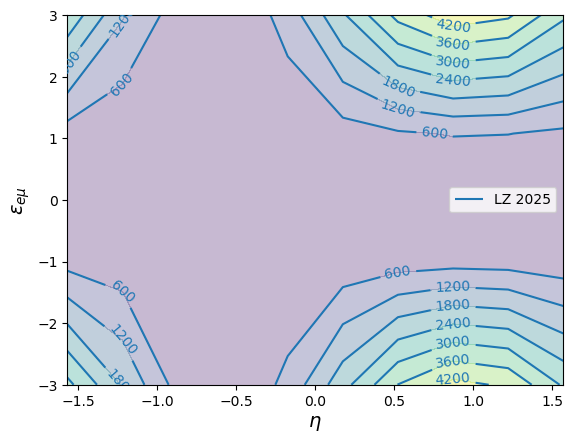

In [12]:
fig, ax = plt.subplots()

plt.contourf(etaGrid, epsGrid, N_LZ, alpha=0.3) 
contLZ = plt.contour(etaGrid, epsGrid, N_LZ, colors='tab:blue') 

plt.clabel(contLZ, inline=1, fontsize=10)

h1,l1 = contLZ.legend_elements()
plt.legend([h1[0]], ["LZ 2025"])

plt.ylabel(r'$\varepsilon_{e\mu}$', size=14)
plt.xlabel(r'$\eta$', size=14)

## Plot exclusion limit

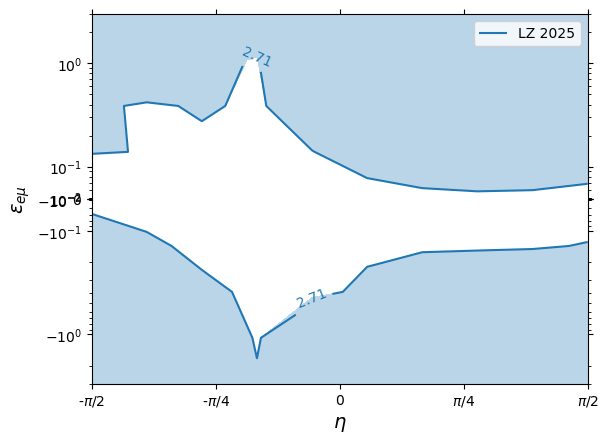

In [13]:
import matplotlib.ticker as tck



# # 2D 90% C.L. chi square
# q_crit = 4.61
# 1D 90% C.L. chi square
q_crit = 2.71

# Figure
fig, ax = plt.subplots()

plt.contourf(etaGrid, epsGrid, Tstat_LZ, levels=[q_crit, np.inf], colors='tab:blue', alpha=0.3) 
contLZ = plt.contour(etaGrid, epsGrid, Tstat_LZ, levels=[q_crit], colors='tab:blue') 

plt.clabel(contLZ, inline=1, fontsize=10)

h1,l1 = contLZ.legend_elements()
plt.legend([h1[0]], ["LZ 2025"])

ax.set_yscale('symlog', linthresh=0.05, linscale=0.01)
# ax.yaxis.set_minor_locator(tck.AutoMinorLocator())
ax.set_xticks(np.pi*np.array([-1./2, -1./4, 0, 1./4, 1./2]), [r'-$\pi/2$', r'-$\pi/4$', '0', r'$\pi/4$', r'$\pi/2$'])
ax.set_yticks(np.outer(np.array([-0.01, -0.1, -1, 0.01, 0.1, 1]),np.array([2, 3, 4 , 5, 6, 7, 8, 9])).flatten(), minor=True)
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.set_ylim(-3, 3)
plt.ylabel(r'$\varepsilon_{e\mu}$', size=14)
plt.xlabel(r'$\eta$', size=14)
plt.savefig("eps_emu_LL.png", bbox_inches='tight')




# Save data to file
#np.savetxt("events_LZ25.csv", np.array([epsGrid, etaGrid, N_LZ, Tstat_LZ]), header="2D data grids: eps, phi, nevents, test_stat", delimiter=",")
# np.save("events_LZ25.npy", np.array([epsGrid, etaGrid, N_LZ, Tstat_LZ]))

## Data storage

### Saving to CSV file

In [16]:
import pandas as pd

print(epsGrid.shape, etaGrid.shape, N_LZ.shape, Tstat_LZ.shape)

print("Saving data to CSV file...")
df = pd.DataFrame({
    'eps': epsGrid.flatten(),
    'eta': etaGrid.flatten(),
    # 'N_XNT': N_XNT.flatten(),
    # 'Tstat_XNT': Tstat_XNT.flatten(),
    # 'N_PANDA': N_PANDA.flatten(),
    # 'Tstat_PANDA': Tstat_PANDA.flatten(),
    'N_LZ': N_LZ.flatten(),
    'Tstat_LZ': Tstat_LZ.flatten()
})

job = ''
if   nsi_elem == 1: job = 'ee'
elif nsi_elem == 2: job = 'mumu'
elif nsi_elem == 3: job = 'tautau'
elif nsi_elem == 4: job = 'emu'
elif nsi_elem == 5: job = 'e tau'
elif nsi_elem == 6: job = 'mu tau'

df.to_csv("NR_scan_{}.csv".format(job), index=False)   

(10, 10) (10, 10) (10, 10) (10, 10)
Saving data to CSV file...


### Loading data from CSV file

In [ ]:
# load file
df = pd.read_csv("events_LZ25.csv")


# Determine the shape of the original grids
nx = df["eps"].nunique()
ny = df["eta"].nunique()    


epsGrid_loaded = df['eps'].values.reshape((nx, ny))
etaGrid_loaded = df['eta'].values.reshape((nx, ny))
N_LZ_loaded    = df['N_LZ'].values.reshape((nx, ny))
Tstat_LZ_loaded = df['Tstat_LZ'].values.reshape((nx, ny))
